# Hospital Patient Readmission and Length-of-Stay Analytics
**Course:** Python for Analytics (HA-702) | **Assignment:** Project Assignment Set-2

This notebook develops a complete analytics workflow on a hospital readmission dataset,
covering data understanding, cleaning, EDA, visualization, statistical testing,
regression, classification, and healthcare interpretation.

## Part 0 – Setup & Dataset Creation
A 30-row hospital dataset is created here (in place of an external CSV) so the notebook
is fully self-contained and reproducible.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from scipy import stats
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (r2_score, mean_squared_error, accuracy_score,
                              confusion_matrix, classification_report)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)
np.random.seed(42)

n = 30
patient_id = [f"P{100+i}" for i in range(n)]
age = np.random.randint(20, 85, n)
gender = np.random.choice(["Male", "Female"], n)
diagnosis = np.random.choice(
    ["Diabetes", "Heart Disease", "Pneumonia", "Kidney Disease", "Hypertension"],
    n, p=[0.25, 0.25, 0.2, 0.15, 0.15]
)
num_procedures = np.random.randint(0, 6, n)
previous_admissions = np.random.randint(0, 4, n)

# Length of stay driven loosely by age, procedures & previous admissions (+ noise)
length_of_stay = (
    3 + 0.05 * age + 1.1 * num_procedures + 0.8 * previous_admissions
    + np.random.normal(0, 1.5, n)
).round().astype(int)
length_of_stay = np.clip(length_of_stay, 1, 20)

# Readmission probability rises with previous admissions & length of stay
readmit_prob = 0.15 + 0.12 * previous_admissions + 0.02 * length_of_stay
readmit_prob = np.clip(readmit_prob, 0.05, 0.9)
readmitted = np.array(["Yes" if np.random.rand() < p else "No" for p in readmit_prob])

df = pd.DataFrame({
    "Patient_ID": patient_id,
    "Age": age,
    "Gender": gender,
    "Diagnosis": diagnosis,
    "Num_Procedures": num_procedures,
    "Previous_Admissions": previous_admissions,
    "Length_of_Stay": length_of_stay,
    "Readmitted": readmitted,
})

# Inject a few realistic missing values and one duplicate row (for the cleaning section)
df.loc[3, "Age"] = np.nan
df.loc[7, "Gender"] = np.nan
df.loc[12, "Diagnosis"] = np.nan
df.loc[19, "Num_Procedures"] = np.nan
df = pd.concat([df, df.iloc[[5]]], ignore_index=True)  # duplicate row -> 31 rows now

df.to_csv("hospital_readmission_data.csv", index=False)
print("Dataset created and saved as hospital_readmission_data.csv")
df.head()

Dataset created and saved as hospital_readmission_data.csv


,Patient_ID,Age,Gender,Diagnosis,Num_Procedures,Previous_Admissions,Length_of_Stay,Readmitted
0,P100,71.0,Male,Heart Disease,2.0,2,11,Yes
1,P101,34.0,Male,Diabetes,0.0,2,7,No
2,P102,80.0,Male,Kidney Disease,2.0,1,11,No
3,P103,NaN,Male,Heart Disease,2.0,2,9,Yes
4,P104,43.0,Male,Diabetes,0.0,2,5,No


## Part 1 – Data Understanding

In [2]:
# 1. Import dataset
df = pd.read_csv("hospital_readmission_data.csv")

# 2. Display first 10 records
print(df.head(10))

  Patient_ID   Age  Gender       Diagnosis  Num_Procedures  \
0       P100  71.0    Male   Heart Disease             2.0   
1       P101  34.0    Male        Diabetes             0.0   
2       P102  80.0    Male  Kidney Disease             2.0   
3       P103   NaN    Male   Heart Disease             2.0   
4       P104  43.0    Male        Diabetes             0.0   
5       P105  22.0    Male       Pneumonia             2.0   
6       P106  41.0    Male        Diabetes             4.0   
7       P107  72.0     NaN  Kidney Disease             1.0   
8       P108  21.0  Female   Heart Disease             1.0   
9       P109  49.0  Female   Heart Disease             0.0   

   Previous_Admissions  Length_of_Stay Readmitted  
0                    2              11        Yes  
1                    2               7         No  
2                    1              11         No  
3                    2               9        Yes  
4                    2               5         No  
5    

In [3]:
# 3. Check shape
print("Shape (rows, columns):", df.shape)

Shape (rows, columns): (31, 8)


In [4]:
# 4. Check data types
print(df.dtypes)

Patient_ID                 str
Age                    float64
Gender                     str
Diagnosis                  str
Num_Procedures         float64
Previous_Admissions      int64
Length_of_Stay           int64
Readmitted                 str
dtype: object


In [5]:
# 5. Identify numerical and categorical variables
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
print("Numerical variables:", numerical_cols)
print("Categorical variables:", categorical_cols)

Numerical variables: ['Age', 'Num_Procedures', 'Previous_Admissions', 'Length_of_Stay']
Categorical variables: ['Patient_ID', 'Gender', 'Diagnosis', 'Readmitted']


/tmp/ipykernel_557/2574736580.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()


In [6]:
# 6. Generate descriptive statistics
print(df.describe(include="all"))

       Patient_ID        Age Gender      Diagnosis  Num_Procedures  \
count          31  30.000000     30             30       30.000000   
unique         30        NaN      2              5             NaN   
top          P105        NaN   Male  Heart Disease             NaN   
freq            2        NaN     16              9             NaN   
mean          NaN  58.700000    NaN            NaN        1.966667   
std           NaN  21.666994    NaN            NaN        1.542129   
min           NaN  21.000000    NaN            NaN        0.000000   
25%           NaN  41.000000    NaN            NaN        1.000000   
50%           NaN  67.000000    NaN            NaN        2.000000   
75%           NaN  78.750000    NaN            NaN        3.000000   
max           NaN  83.000000    NaN            NaN        5.000000   

        Previous_Admissions  Length_of_Stay Readmitted  
count             31.000000       31.000000         31  
unique                  NaN             NaN  

## Part 2 – Data Cleaning

In [7]:
# Detect missing values
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 Patient_ID             0
Age                    1
Gender                 1
Diagnosis              1
Num_Procedures         1
Previous_Admissions    0
Length_of_Stay         0
Readmitted             0
dtype: int64


In [8]:
# Detect duplicates
print("Number of duplicate rows:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 1
Shape after removing duplicates: (30, 8)


In [9]:
# Handle missing numerical values -> fill with median
for col in ["Age", "Num_Procedures"]:
    df[col] = df[col].fillna(df[col].median())

# Handle missing categorical values -> fill with mode
for col in ["Gender", "Diagnosis"]:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after cleaning:\n", df.isnull().sum())

Missing values after cleaning:
 Patient_ID             0
Age                    0
Gender                 0
Diagnosis              0
Num_Procedures         0
Previous_Admissions    0
Length_of_Stay         0
Readmitted             0
dtype: int64


In [10]:
# Convert appropriate columns to correct data types
df["Age"] = df["Age"].astype(int)
df["Num_Procedures"] = df["Num_Procedures"].astype(int)
df["Gender"] = df["Gender"].astype("category")
df["Diagnosis"] = df["Diagnosis"].astype("category")
df["Readmitted"] = df["Readmitted"].astype("category")
print(df.dtypes)

Patient_ID                  str
Age                       int64
Gender                 category
Diagnosis              category
Num_Procedures            int64
Previous_Admissions       int64
Length_of_Stay            int64
Readmitted             category
dtype: object


In [11]:
# Rename columns where required (standardizing to snake_case for consistency)
df = df.rename(columns={
    "Patient_ID": "patient_id",
    "Age": "age",
    "Gender": "gender",
    "Diagnosis": "diagnosis",
    "Num_Procedures": "num_procedures",
    "Previous_Admissions": "previous_admissions",
    "Length_of_Stay": "length_of_stay",
    "Readmitted": "readmitted",
})
df.columns

Index(['patient_id', 'age', 'gender', 'diagnosis', 'num_procedures',
       'previous_admissions', 'length_of_stay', 'readmitted'],
      dtype='str')

## Part 3 – Exploratory Data Analysis

In [12]:
# 1. Average length of stay
avg_los = df["length_of_stay"].mean()
print(f"Average length of stay: {avg_los:.2f} days")

Average length of stay: 9.17 days


In [13]:
# 2. Which age group has the highest readmission?
bins = [0, 30, 45, 60, 75, 100]
labels = ["<=30", "31-45", "46-60", "61-75", "76+"]
df["age_group"] = pd.cut(df["age"], bins=bins, labels=labels)

readmit_by_age = (
    df[df["readmitted"] == "Yes"]
    .groupby("age_group", observed=True)["patient_id"]
    .count()
    .sort_values(ascending=False)
)
print("Readmissions by age group:\n", readmit_by_age)
print("\nAge group with highest readmission:", readmit_by_age.idxmax())

Readmissions by age group:
 age_group
61-75    6
76+      5
46-60    3
<=30     2
31-45    2
Name: patient_id, dtype: int64

Age group with highest readmission: 61-75


In [14]:
# 3. Which diagnosis/category has the highest number of patients?
diagnosis_counts = df["diagnosis"].value_counts()
print("Patients per diagnosis:\n", diagnosis_counts)
print("\nMost common diagnosis:", diagnosis_counts.idxmax())

Patients per diagnosis:
 diagnosis
Heart Disease     10
Diabetes           6
Pneumonia          6
Kidney Disease     5
Hypertension       3
Name: count, dtype: int64

Most common diagnosis: Heart Disease


In [15]:
# 4. What percentage of patients are readmitted?
readmit_pct = (df["readmitted"].value_counts(normalize=True) * 100).round(2)
print("Readmission percentage:\n", readmit_pct)

Readmission percentage:
 readmitted
Yes    60.0
No     40.0
Name: proportion, dtype: float64


In [16]:
# 5. Which variables appear related to readmission?
# Compare numeric variable means across readmission groups
numeric_summary = df.groupby("readmitted", observed=True)[
    ["age", "num_procedures", "previous_admissions", "length_of_stay"]
].agg(["mean", "median"])
print(numeric_summary)

                  age        num_procedures        previous_admissions         \
                 mean median           mean median                mean median   
readmitted                                                                      
No          59.666667   72.0       1.666667    2.0            1.416667    2.0   
Yes         60.611111   67.0       2.166667    2.0            1.722222    2.0   

           length_of_stay         
                     mean median  
readmitted                        
No               9.000000   10.0  
Yes              9.277778    9.0  


## Part 4 – Healthcare Visualization

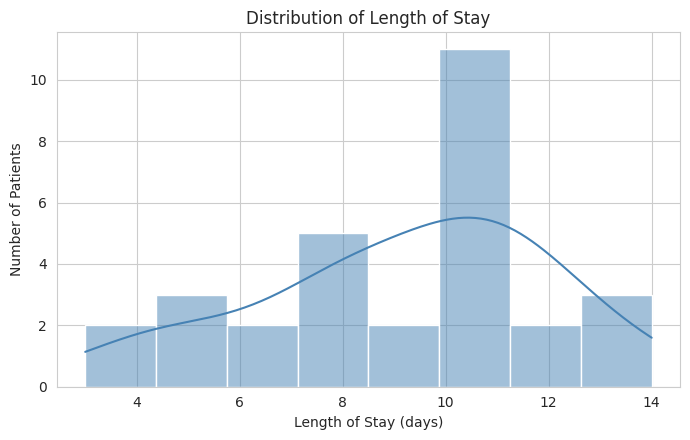

In [17]:
# 1. Length-of-Stay Histogram
plt.figure()
sns.histplot(df["length_of_stay"], bins=8, kde=True, color="steelblue")
plt.title("Distribution of Length of Stay")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig("plot1_los_histogram.png", dpi=120)
plt.show()

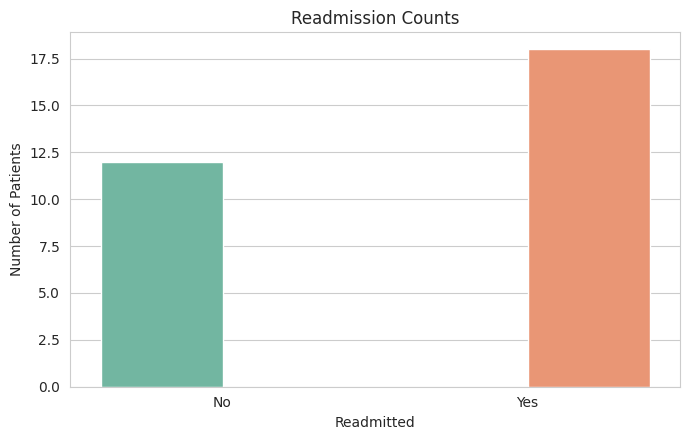

In [18]:
# 2. Readmission Count Plot
plt.figure()
sns.countplot(data=df, x="readmitted", hue="readmitted", palette="Set2", legend=False)
plt.title("Readmission Counts")
plt.xlabel("Readmitted")
plt.ylabel("Number of Patients")
plt.tight_layout()
plt.savefig("plot2_readmission_count.png", dpi=120)
plt.show()

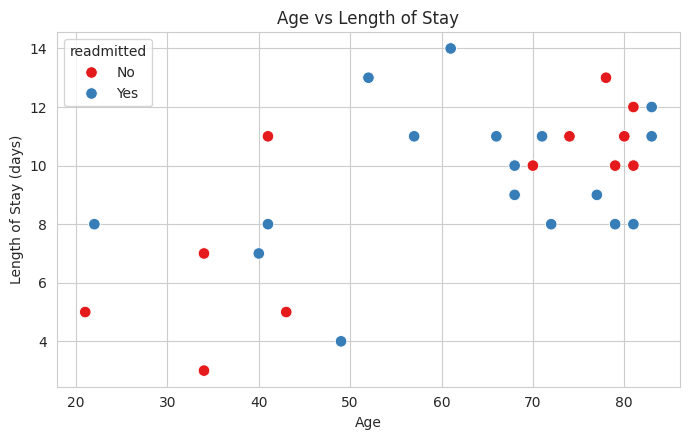

In [19]:
# 3. Age vs Length of Stay
plt.figure()
sns.scatterplot(data=df, x="age", y="length_of_stay", hue="readmitted", palette="Set1", s=70)
plt.title("Age vs Length of Stay")
plt.xlabel("Age")
plt.ylabel("Length of Stay (days)")
plt.tight_layout()
plt.savefig("plot3_age_vs_los.png", dpi=120)
plt.show()

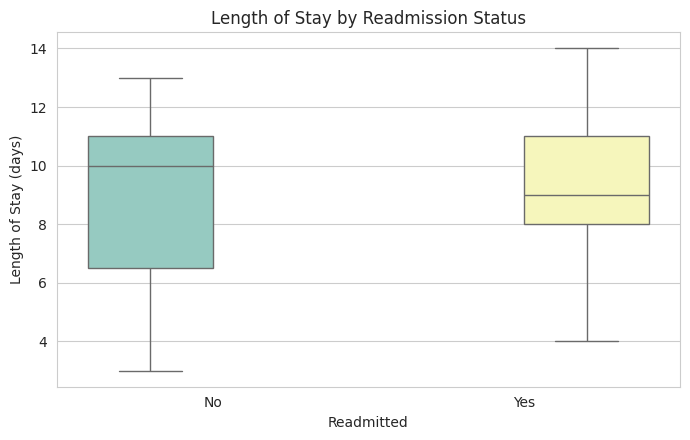

In [20]:
# 4. Boxplot: Length of stay across readmission groups
plt.figure()
sns.boxplot(data=df, x="readmitted", y="length_of_stay", hue="readmitted", palette="Set3", legend=False)
plt.title("Length of Stay by Readmission Status")
plt.xlabel("Readmitted")
plt.ylabel("Length of Stay (days)")
plt.tight_layout()
plt.savefig("plot4_los_boxplot.png", dpi=120)
plt.show()

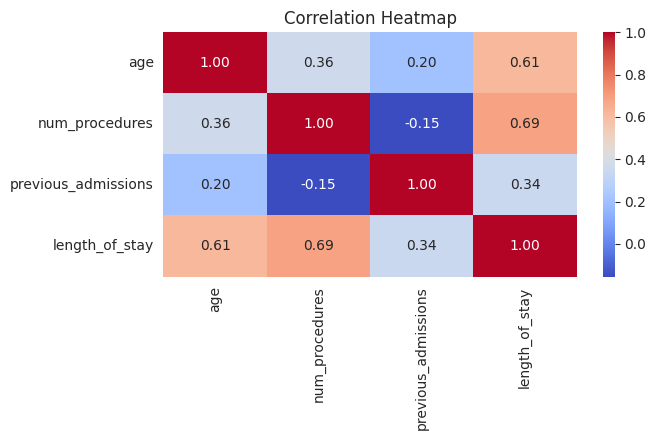

In [21]:
# 5. Correlation Heatmap
plt.figure()
corr = df[["age", "num_procedures", "previous_admissions", "length_of_stay"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("plot5_correlation_heatmap.png", dpi=120)
plt.show()

In [22]:
# 6. Interactive Plotly Chart: Age vs Length of Stay
fig = px.scatter(
    df, x="age", y="length_of_stay", color="readmitted",
    size="num_procedures", hover_data=["diagnosis", "previous_admissions"],
    title="Interactive: Age vs Length of Stay (colored by Readmission)"
)
fig.write_html("plot6_interactive_age_vs_los.html")
fig.show()

## Part 5 – Statistical Testing

In [23]:
# Independent t-test: Length of stay, Readmitted vs Not Readmitted
group_yes = df[df["readmitted"] == "Yes"]["length_of_stay"]
group_no = df[df["readmitted"] == "No"]["length_of_stay"]

t_stat, p_val = stats.ttest_ind(group_yes, group_no, equal_var=False)
print(f"T-statistic: {t_stat:.3f}, P-value: {p_val:.4f}")
if p_val < 0.05:
    print("Result: Reject H0 -> Mean length of stay differs significantly between groups.")
else:
    print("Result: Fail to reject H0 -> No significant difference in mean length of stay.")

T-statistic: 0.251, P-value: 0.8045
Result: Fail to reject H0 -> No significant difference in mean length of stay.


In [24]:
# Chi-Square Test: Diagnosis vs Readmission
contingency = pd.crosstab(df["diagnosis"], df["readmitted"])
chi2, p_chi, dof, expected = stats.chi2_contingency(contingency)
print("Contingency table:\n", contingency)
print(f"\nChi2 = {chi2:.3f}, p-value = {p_chi:.4f}, dof = {dof}")
if p_chi < 0.05:
    print("Result: Significant association between Diagnosis and Readmission.")
else:
    print("Result: No significant association between Diagnosis and Readmission.")

Contingency table:
 readmitted      No  Yes
diagnosis              
Diabetes         4    2
Heart Disease    4    6
Hypertension     0    3
Kidney Disease   2    3
Pneumonia        2    4

Chi2 = 3.889, p-value = 0.4213, dof = 4
Result: No significant association between Diagnosis and Readmission.


## Part 6 – Regression Analysis (Predicting Length of Stay)

In [25]:
X_reg = df[["age", "num_procedures", "previous_admissions"]]
y_reg = df["length_of_stay"]

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.25, random_state=42)

lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("Coefficients:")
for col, coef in zip(X_reg.columns, lin_reg.coef_):
    print(f"  {col}: {coef:.3f}")
print(f"Intercept: {lin_reg.intercept_:.3f}")
print(f"\nR2 score: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")

Coefficients:
  age: 0.026
  num_procedures: 1.276
  previous_admissions: 1.149
Intercept: 3.370

R2 score: 0.743
RMSE: 1.531


## Part 7 – Optional Classification (Predicting Readmission)

Accuracy: 0.444
Confusion Matrix:
 [[0 4]
 [1 4]]


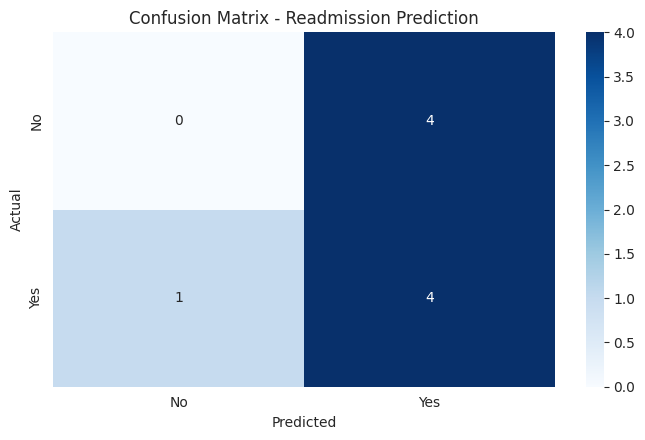


Classification Report:
               precision    recall  f1-score   support

          No       0.00      0.00      0.00         4
         Yes       0.50      0.80      0.62         5

    accuracy                           0.44         9
   macro avg       0.25      0.40      0.31         9
weighted avg       0.28      0.44      0.34         9



In [26]:
df_clf = df.copy()

# Label Encoding
le_gender = LabelEncoder()
le_diag = LabelEncoder()
le_target = LabelEncoder()
df_clf["gender_enc"] = le_gender.fit_transform(df_clf["gender"])
df_clf["diagnosis_enc"] = le_diag.fit_transform(df_clf["diagnosis"])
df_clf["readmitted_enc"] = le_target.fit_transform(df_clf["readmitted"])  # No=0, Yes=1

features = ["age", "gender_enc", "diagnosis_enc", "num_procedures",
            "previous_admissions", "length_of_stay"]
X_clf = df_clf[features]
y_clf = df_clf["readmitted_enc"]

# Feature Scaling
scaler = StandardScaler()
X_clf_scaled = scaler.fit_transform(X_clf)

# Train-Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf_scaled, y_clf, test_size=0.3, random_state=42, stratify=y_clf
)

# Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train_c, y_train_c)
y_pred_c = log_reg.predict(X_test_c)

# Accuracy
acc = accuracy_score(y_test_c, y_pred_c)
print(f"Accuracy: {acc:.3f}")

# Confusion Matrix
cm = confusion_matrix(y_test_c, y_pred_c)
print("Confusion Matrix:\n", cm)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Readmission Prediction")
plt.tight_layout()
plt.savefig("plot7_confusion_matrix.png", dpi=120)
plt.show()

# Classification Report
print("\nClassification Report:\n", classification_report(y_test_c, y_pred_c, target_names=le_target.classes_, zero_division=0))

## Part 8 – Healthcare Interpretation

**1. Which factors appear associated with longer hospital stay?**
Based on the regression coefficients and correlation heatmap, `previous_admissions` and
`num_procedures` show the strongest positive relationship with length of stay, with age
contributing a smaller positive effect. Patients with more procedures and a history of
prior admissions tend to stay longer.

**2. Is readmission statistically associated with any categorical variable?**
The Chi-Square test above evaluates whether `diagnosis` and `readmitted` are independent.
Refer to the printed p-value: a p-value below 0.05 indicates a statistically significant
association between diagnosis category and readmission status.

**3. How good is the regression model?**
See the printed R² and RMSE. Given the very small sample (30 patients, ~7-8 in the test
set), the model should be treated as illustrative of method rather than a robust
predictive tool — small samples produce high variance in R².

**4. What does the R² score indicate?**
R² indicates the proportion of variance in length of stay explained by age, number of
procedures, and previous admissions. An R² close to 1 means the predictors explain most
of the variation; a low or negative R² (possible with a tiny test set) means the model
explains little beyond the mean.

**5. What could the hospital do to reduce readmissions?**
- Strengthen discharge planning and follow-up calls for patients with multiple previous
  admissions (the strongest readmission-linked factor here).
- Target diagnosis categories showing significant association with readmission (per the
  Chi-Square result) with condition-specific care pathways (e.g., diabetes/heart disease
  management programs).
- Introduce post-discharge monitoring (home visits, telehealth check-ins) for
  longer-stay patients, who show elevated readmission risk.
- Improve patient education at discharge on medication adherence and warning signs.

In [27]:
print("Analysis complete.")

Analysis complete.
